# Figure2(Stackedbar) for bertopic

In [40]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_10): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [41]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.date_setting import Date_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic)
mpl.rcParams['font.family'] = font_setting.init_font()

Helvetica /home/mghan/.fonts/Helvetica/Helvetica Bold Oblique.ttf
Registered font name: Helvetica


In [42]:
color_list = Color_Setting.color_list
alpha_list = [1, 1, 0.7]

In [43]:
viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")

output_dir = './fig/'
date_range = 'Weekly'

std_date = Date_Setting[option_dict['year_range']]['std_date']

In [44]:
df = load_df(data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])

In [45]:
df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed").dt.normalize()
# df['cdate'] = pd.to_datetime(df['creationdate'], format="%Y-%m-%d").dt.date
df['rel_week'] = ((df['creationdate'] - std_date).dt.days // 7)
# df.sort_values(by = ['cdate']).reset_index(drop=True, inplace=True)

In [46]:
prop_df = proportion_calc_for_topic(df, 'rel_week', 'Topic')

In [47]:
top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
               'Bottom 20% Topics' : bot10list}


df_dict = {'Top 20% Topics'       : prop_df[prop_df['Topic'].isin(top10list)],   
          'Bottom 20% Topics'     : prop_df[prop_df['Topic'].isin(bot10list)]}

    


In [48]:
# calculate entropy and gini by weekly manner
df_coef = {'Entropy' : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_entropy(x)).to_frame(name='Entropy').reset_index(),
           'Gini'    : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_gini(x)).to_frame(name = 'Gini').reset_index()}

In [49]:
# calculate the proportion weekly manner
# prop_df = pd.merge( df.groupby(['rel_week', 'Topic']).count()['id'].reset_index().rename(columns={'id': 'cnt'}),
#                         df.groupby(['rel_week']).count()['id'].reset_index().rename(columns={'id': 'tot_cnt'}), on = 'rel_week')
# prop_df['proportion'] = prop_df['cnt']/prop_df['tot_cnt']

In [50]:
# topic_list = list(prop_df[prop_df['rel_week'] <0].groupby('Topic').sum()['proportion'].reset_index().sort_values(by = 'proportion', ascending=False)['Topic'])
# top10list = topic_list[:10]
# bot10list = topic_list[-10:]
# mid30list = np.setdiff1d(np.arange(0,50), top10list)
# mid30list = np.setdiff1d(mid30list, bot10list)



In [51]:
plot_gen = PlotGen.PlotGen()

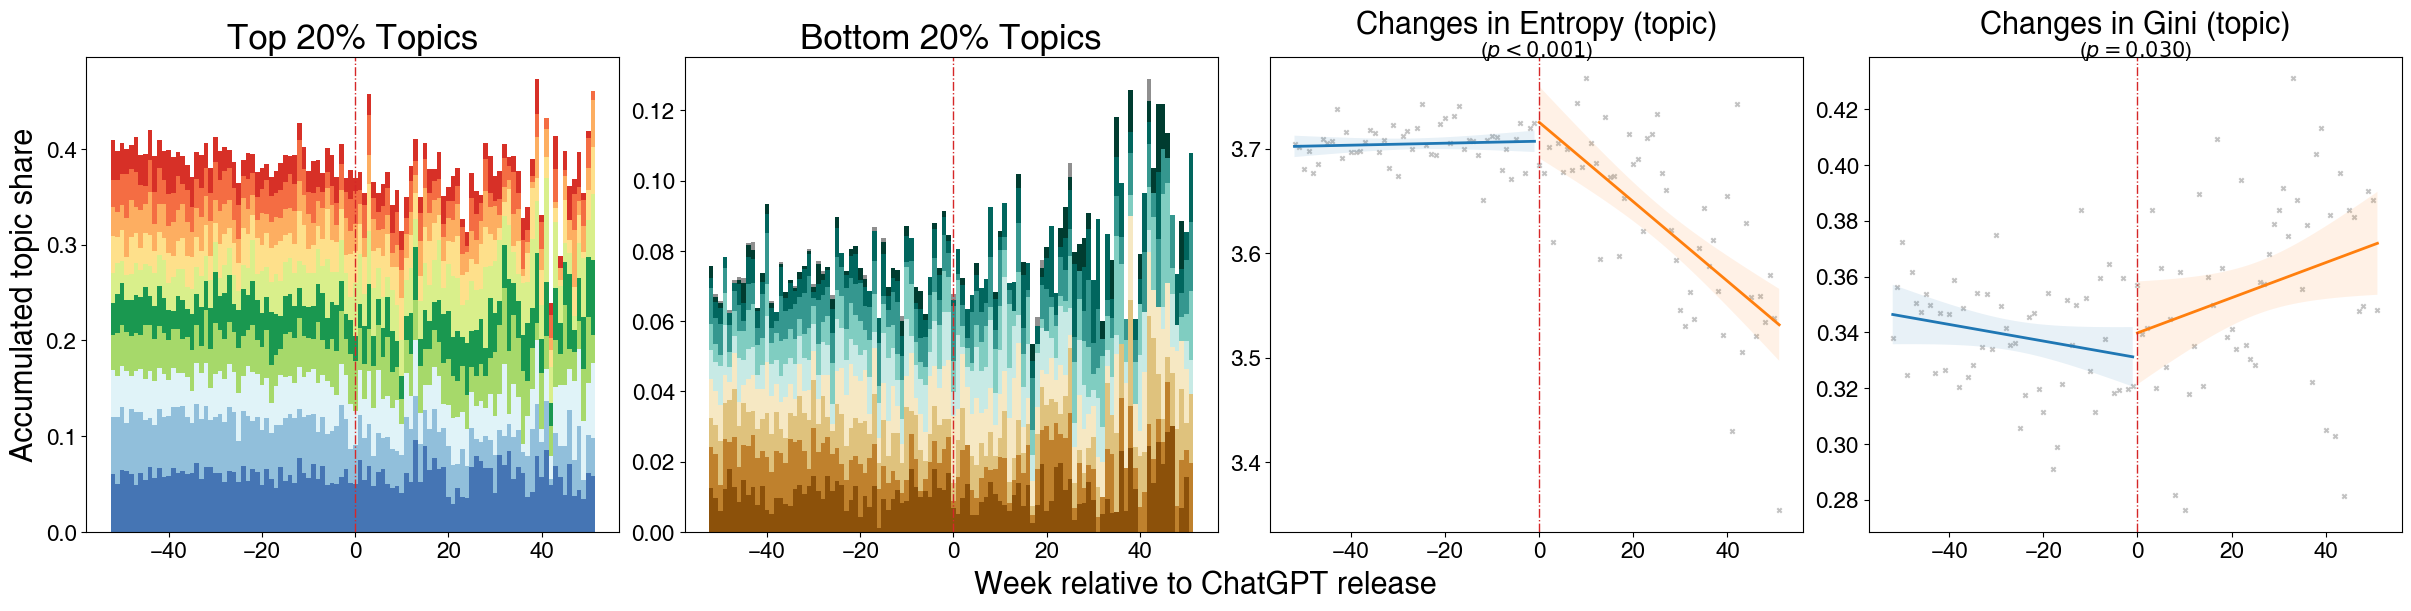

In [52]:
fig, axs = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

### stacked topic plots
for i, (title, proportion) in enumerate(df_dict.items()):

    plot_gen.draw_topic_stack(
        axs[i],
        title,
        proportion,
        list_10[title],
        color_list[i],
        alpha_list[i]
    )

axs[0].set_ylabel("Accumulated topic share", fontsize=22)


### regression plots
buff = 2

for j, (title, proportion) in enumerate(df_coef.items()):

    series = proportion[title]

    plot_gen.draw_regression(
        axs[j + buff],
        title,
        series
    )


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)

plt.savefig(f"{output_dir}C_Result_Fig2_2.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
top10list
# , bot10list